# Differential Expression: Advanced Options

Building on [Getting Started](./01_getting_started.ipynb), this notebook covers the
knobs you reach for on real projects:

- tuning DE parameters,
- running and tracking **multiple comparisons**,
- reproducing a past run,
- planning memory and disk before a long job,
- advanced FDR and volcano options.

The statistical background is in the
[paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769).

In [1]:
%matplotlib inline

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import palantir
import pandas as pd
import scanpy as sc

import kompot

# Consistent, clean plotting style across the tutorial set
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

/fh/fast/setty_m/user/dotto/nexus/work/kompot-080/.venv-312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"
GROUPING_COLUMN = "Age"
CONDITIONS = ["Young", "Old"]
CELL_TYPE_COLUMN = "highres_celltype"
DIMENSIONALITY_REDUCTION = "DM_EigenVectors"
LAYER_FOR_EXPRESSION = "logged_counts"

## Load Data

Same dataset as the first tutorial:

In [3]:
adata = ad.read_h5ad(DATA_PATH)
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40)
adata

/fh/fast/setty_m/user/dotto/nexus/work/kompot-080/.venv-312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/fh/fast/setty_m/user/dotto/nexus/work/kompot-080/.venv-312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'DM_EigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_

## Tuning DE Parameters

Advanced options are grouped into Settings dataclasses; any field left at its default
is the same as omitting it.

- **`GPSettings`** — GP model: `sigma` (noise level), `ls_factor` (smoothness of the
  expression function — see *Controlling smoothness* below), `n_landmarks`
  (accuracy vs. speed), `batch_size` (peak memory; `0` = all cells at once).
- **`FDRSettings`** — `null_genes` (permuted genes for FDR; more = better estimate, slower),
  `threshold` (the FDR used for `is_de`).
- **`StorageSettings`** — `result_key` (field-name prefix; change it to keep several runs side by side).

In [4]:
de_results = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    gp=kompot.GPSettings(batch_size=0),
    fdr=kompot.FDRSettings(null_genes=4000),   # more null genes = tighter FDR
)

[2026-07-28 13:48:29,271] [INFO    ] Condition 1 (Young): 2,917 cells


[2026-07-28 13:48:29,272] [INFO    ] Condition 2 (Old): 3,116 cells


[2026-07-28 13:48:35,238] [INFO    ] Fitting expression estimator for condition 1...


[2026-07-28 13:49:07,429] [INFO    ] Fitting expression estimator for condition 2...


[2026-07-28 13:50:39,660] [INFO    ] FDR analysis complete: 50/16285 genes significantly DE at FDR < 0.05


[2026-07-28 13:50:39,661] [INFO    ] Mahalanobis distance threshold for FDR < 0.05: 7.4159


[2026-07-28 13:50:46,281] [INFO    ] This run will have `run_id=0`.


## Advanced Volcano Options

The y-axis defaults to Mahalanobis distance. Switch it to local FDR, and set
per-metric significance thresholds:

[2026-07-28 13:50:46,928] [INFO    ] Found DE run info for run_id=-1


[2026-07-28 13:50:46,931] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info


[2026-07-28 13:50:46,932] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info


[2026-07-28 13:50:46,934] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}


[2026-07-28 13:50:46,934] [INFO    ] Using local_fdr values for y-axis: kompot_de_Young_to_Old_mahalanobis_local_fdr


...

[2026-07-28 13:50:46,951] [INFO    ] Values range: 0.000000 - 1.000000


[2026-07-28 13:50:46,955] [INFO    ] Found 44 genes with local_fdr < 0.02


[2026-07-28 13:50:46,959] [INFO    ] Highlighting 44 genes at local_fdr < 0.02 (26 up, 18 down)


[2026-07-28 13:50:46,973] [INFO    ] Labeling top 10 genes by score


[2026-07-28 13:50:46,979] [INFO    ] Added local_fdr threshold line at y=1.70 (local_fdr=0.02)


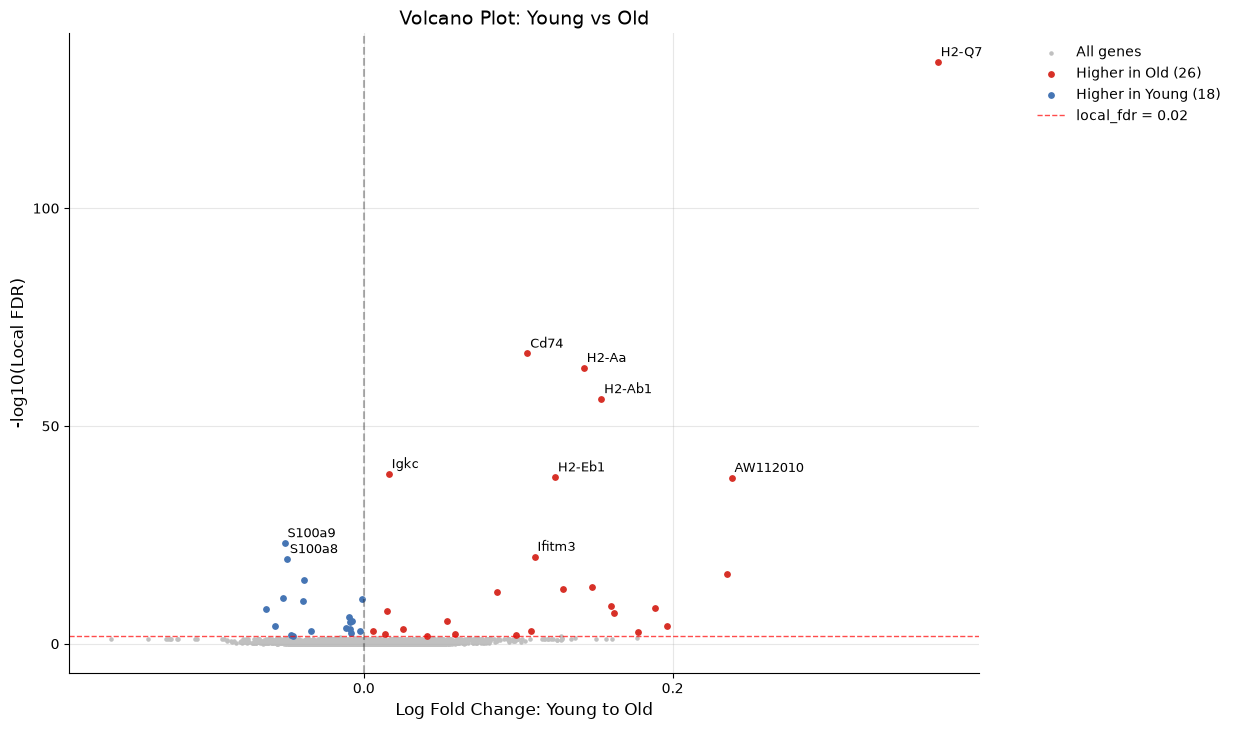

In [5]:
kompot.plot.volcano_de(
    adata,
    y_axis_type="local_fdr",
    significance_threshold=0.02,
)

`significance_threshold` accepts a dict to combine criteria, and `gene_labels` can be a
list, a `{gene: label}` dict, or an integer to auto-label the top N genes.

Note how the Mahalanobis cut is chosen from the data rather than written as a literal.
Mahalanobis distances are not on an absolute scale — they depend on the posterior
covariance, so they shift with the dataset and with the Kompot version (0.8.0 divides
them by √2). A hard-coded number that selects a sensible set on one dataset can select
**nothing** on another. When no gene meets every criterion, `volcano_de` highlights
nothing and warns — an empty highlight is a real negative result, not a failed plot.

The per-criterion counts in the log are worth reading: each threshold reports how many
genes it passes on its own, then how many pass all of them together. If a criterion passes
nearly everything, it is not contributing to the selection.

One caveat specific to this pair: `local_fdr` is *derived from* `mahalanobis`, so the two are
nested by construction — whichever is stricter subsumes the other, and the conjunction can
never be smaller than that. Combining them tightens the selection (44 genes to 33 here) but it
is not two independent lines of evidence. Pairing a significance criterion with an independent
quantity, such as a fold-change magnitude or a `var` column of your own, is where the dict form
earns its keep.


[2026-07-28 13:50:47,422] [INFO    ] Found DE run info for run_id=-1


[2026-07-28 13:50:47,423] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info


[2026-07-28 13:50:47,423] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info


[2026-07-28 13:50:47,424] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}


[2026-07-28 13:50:47,425] [INFO    ] Using DE run 0: comparing Young to Old


...

[2026-07-28 13:50:47,436] [INFO    ] Applied threshold: mahalanobis > 8.038593996180095 (33 genes pass)


[2026-07-28 13:50:47,437] [INFO    ] Found 33 genes passing all thresholds: local_fdr < 0.02 AND mahalanobis > 8.038593996180095


[2026-07-28 13:50:47,440] [INFO    ] Highlighting 33 genes with multiple thresholds (20 up, 13 down)


[2026-07-28 13:50:47,452] [INFO    ] Labeling top 25 genes by score


[2026-07-28 13:50:47,459] [INFO    ] Skipping threshold line drawing for dictionary-format significance_threshold


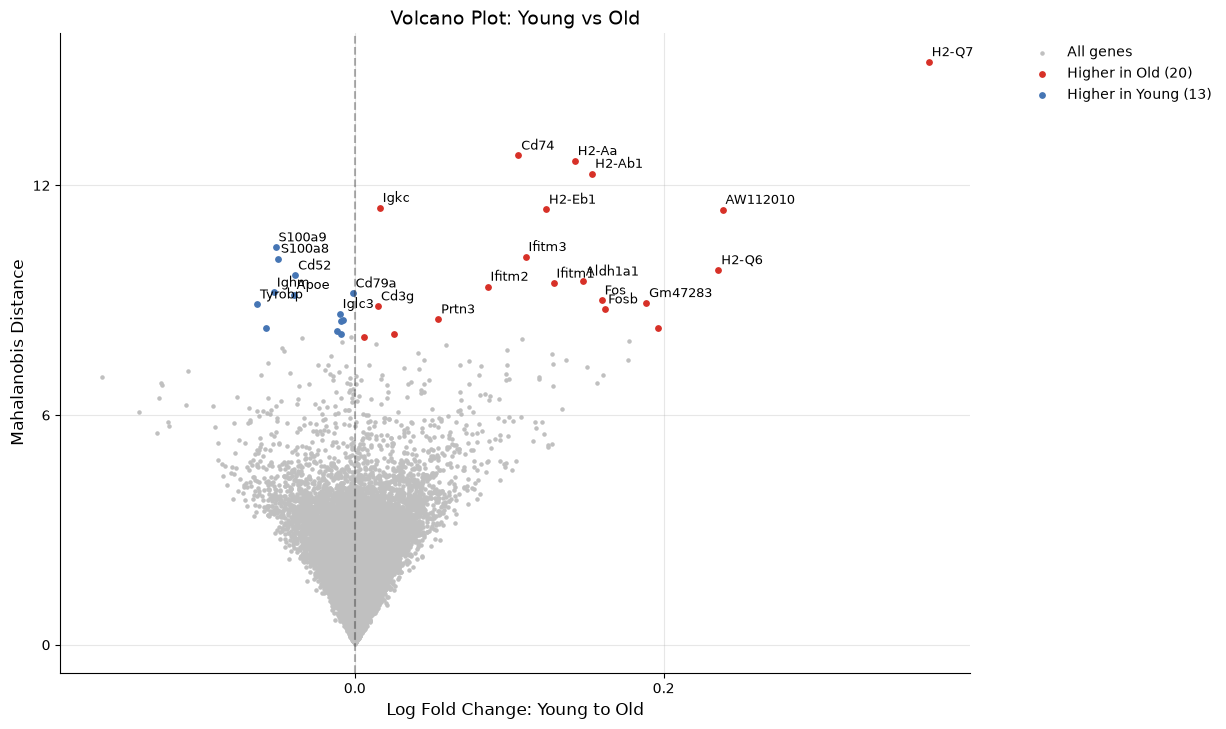

In [6]:
# Take the secondary cut from the observed distribution so the example stays
# meaningful on any dataset, instead of hard-coding a scale-dependent literal.
# A high quantile is what makes the AND do work here: the FDR-significant genes
# already sit far out in the Mahalanobis tail, so a permissive cut would pass all
# of them and the second criterion would be inert.
mahalanobis = adata.var["kompot_de_Young_to_Old_mahalanobis"]
mahalanobis_cut = float(mahalanobis.quantile(0.998))

kompot.plot.volcano_de(
    adata,
    significance_threshold={"local_fdr": 0.02, "mahalanobis": mahalanobis_cut},
    gene_labels=25,
)


## Multiple Comparisons

Kompot tracks every run. Add a second comparison (Young vs. Mid) on the same object;
Kompot warns before overwriting and records which run wrote each field:

In [7]:
de_young_mid = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1="Young",
    condition2="Mid",
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    gp=kompot.GPSettings(batch_size=0),
)

[2026-07-28 13:50:47,948] [WARNING ] Differential expression results with result_key='kompot_de' already exist in the dataset. Previous run was at 2026-07-28T13:50:46.259208 comparing Young to Old. Fields that will be overwritten: layers.kompot_de_Young_smoothed, obs.kompot_de_Young_std Set overwrite=False to prevent overwriting or overwrite=True to silence this message.


[2026-07-28 13:50:47,949] [INFO    ] Condition 1 (Young): 2,917 cells


[2026-07-28 13:50:47,949] [INFO    ] Condition 2 (Mid): 2,057 cells


[2026-07-28 13:50:50,133] [INFO    ] Fitting expression estimator for condition 1...


[2026-07-28 13:51:07,758] [INFO    ] Fitting expression estimator for condition 2...


[2026-07-28 13:52:38,532] [INFO    ] FDR analysis complete: 26/16285 genes significantly DE at FDR < 0.05


[2026-07-28 13:52:38,534] [INFO    ] Mahalanobis distance threshold for FDR < 0.05: 7.2080


[2026-07-28 13:52:44,934] [INFO    ] This run will have `run_id=1`.


Each run gets a `run_id` (`0` first, `1` next, `-1` = most recent). Most plotting
functions accept it:

[2026-07-28 13:52:45,472] [INFO    ] Found DE run info for run_id=0


[2026-07-28 13:52:45,473] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info


[2026-07-28 13:52:45,474] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info


[2026-07-28 13:52:45,475] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' was last written by run 0, but current context expects run 1. The field may have been overwritten.


[2026-07-28 13:52:45,476] [WARNING ] Field 'kompot_de_Young_to_Old_mahalanobis' was last written by run 0, but current context expects run 1. The field may have been overwritten.


...

[2026-07-28 13:52:45,477] [WARNING ] Field inference completed with 2 warnings


[2026-07-28 13:52:45,478] [INFO    ] Using DE run 0: comparing Young to Old


[2026-07-28 13:52:45,486] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis'


[2026-07-28 13:52:45,490] [INFO    ] Highlighting 50 genes marked as DE (31 up, 19 down)


[2026-07-28 13:52:45,503] [INFO    ] Labeling top 30 genes by score


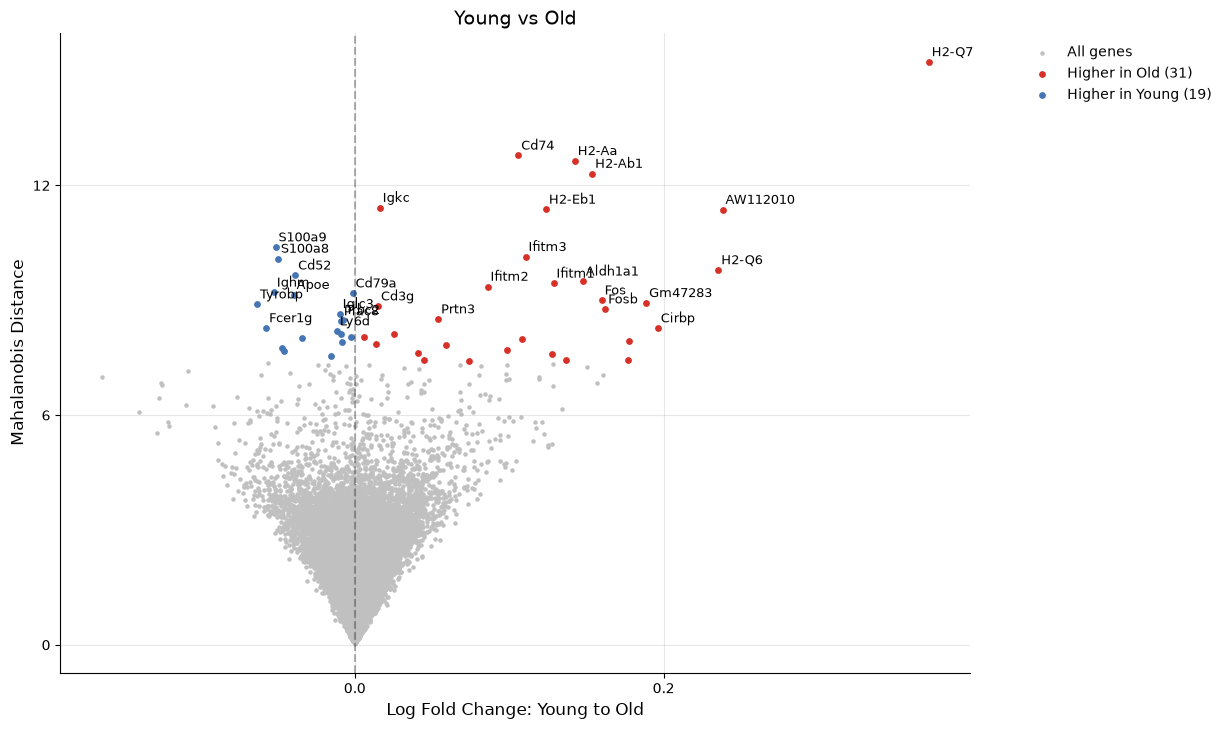

In [8]:
kompot.plot.volcano_de(adata, run_id=0, title="Young vs Old", gene_labels=30)

[2026-07-28 13:52:46,026] [INFO    ] Found DE run info for run_id=1


[2026-07-28 13:52:46,027] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Mid_mean_lfc' from run info


[2026-07-28 13:52:46,027] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Mid_mahalanobis' from run info


[2026-07-28 13:52:46,029] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Mid_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Mid_mahalanobis'}


[2026-07-28 13:52:46,030] [INFO    ] Using DE run 1: comparing Young to Mid


[2026-07-28 13:52:46,036] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Mid_mean_lfc', score: 'kompot_de_Young_to_Mid_mahalanobis'


[2026-07-28 13:52:46,040] [INFO    ] Highlighting 26 genes marked as DE (14 up, 12 down)


[2026-07-28 13:52:46,056] [INFO    ] Labeling top 30 genes by score


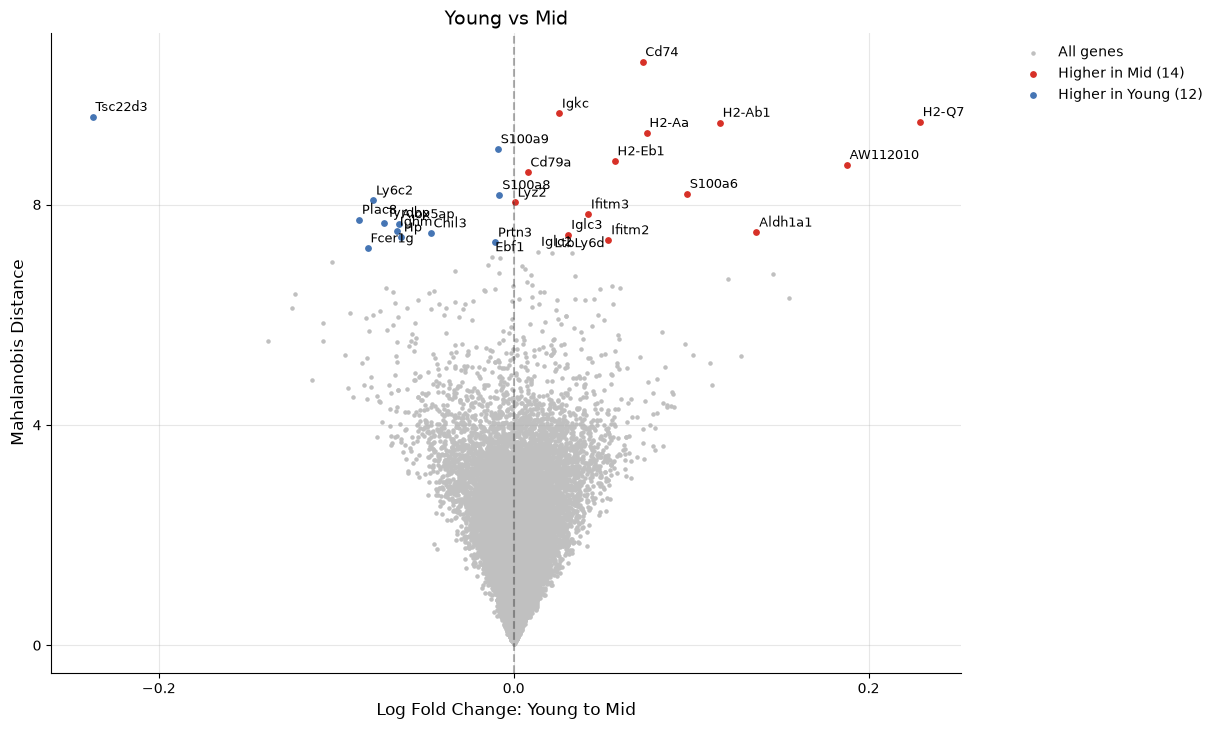

In [9]:
kompot.plot.volcano_de(adata, run_id=1, title="Young vs Mid", gene_labels=30)

## Run Tracking & Reproducibility

Compare the parameters of two runs:

In [10]:
kompot.RunInfo(adata, run_id=0, analysis_type="de").compare_with(1)

RunComparison(run1=0, run2=1, same_fields=2, different_params=2)

`call_args()` returns a kwargs dict that reproduces a run — edit it, then pass it
straight back to `kompot.de`:

In [11]:
run_info = kompot.RunInfo(adata, run_id=0, analysis_type="de")
kwargs = run_info.call_args()

kwargs["fdr"].threshold = 0.01     # tighten FDR
kwargs["gp"].n_landmarks = 3000    # fewer landmarks

# kompot.de(adata, **kwargs)       # re-run with the tweaked parameters
kwargs.keys()

dict_keys(['groupby', 'condition1', 'condition2', 'obsm_key', 'sample_col', 'layer', 'genes', 'gp', 'fdr', 'filter', 'storage', 'output'])

## Controlling smoothness: `ls_factor`

`ls_factor` (a `GPSettings` field, default `10`) scales the length scale of the Gaussian
process that fits each condition's expression function: the automatically inferred length
scale is multiplied by `ls_factor`. A **larger** value stretches that scale, so the fit
pools information across a wider neighborhood of cells — the expression surface gets
**smoother** and its posterior uncertainty **shrinks**, but fine, localized structure is
averaged away (coarser resolution). A **smaller** value does the reverse: a sharper,
higher-resolution surface that follows local variation, at the price of noisier, less
certain estimates. This is the usual resolution-vs-uncertainty trade-off; the
[paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769) covers the theory.

Below is the same Young→Old fit for the top gene at a low vs. high `ls_factor`, on that one
gene with FDR turned off (illustration only). `kompot.de` stores each condition's smoothed
expression as an `adata.layers` entry and the GP's posterior uncertainty as an `adata.obs`
column, so we can project both onto the UMAP:

In [12]:
c1, c2 = CONDITIONS
gene = adata.var[f"kompot_de_{c1}_to_{c2}_mahalanobis"].idxmax()   # top gene from above

for ls_factor, key in [(2.0, "kompot_ls_low"), (30.0, "kompot_ls_high")]:
    kompot.de(
        adata,
        groupby=GROUPING_COLUMN, condition1=c1, condition2=c2,
        layer=LAYER_FOR_EXPRESSION, obsm_key=DIMENSIONALITY_REDUCTION,
        genes=[gene],                                   # one gene keeps it fast
        gp=kompot.GPSettings(ls_factor=ls_factor, batch_size=0),
        fdr=kompot.FDRSettings(null_genes=0),           # no FDR needed for illustration
        storage=kompot.StorageSettings(result_key=key),
    )

[2026-07-28 13:52:46,614] [INFO    ] Condition 1 (Young): 2,917 cells


[2026-07-28 13:52:46,615] [INFO    ] Condition 2 (Old): 3,116 cells


[2026-07-28 13:52:50,232] [INFO    ] Fitting expression estimator for condition 1...


[2026-07-28 13:53:03,577] [INFO    ] Fitting expression estimator for condition 2...


[2026-07-28 13:54:09,210] [INFO    ] Updating 1 genes (0.0% of total) in existing sparse layers: kompot_ls_low_Young_smoothed, kompot_ls_low_Old_smoothed, kompot_ls_low_Young_to_Old_fold_change. Temporarily converting CSR->LIL->CSR.


...

[2026-07-28 13:54:09,311] [INFO    ] Condition 2 (Old): 3,116 cells


[2026-07-28 13:54:12,376] [INFO    ] Fitting expression estimator for condition 1...


[2026-07-28 13:54:27,782] [INFO    ] Fitting expression estimator for condition 2...


[2026-07-28 13:55:32,035] [INFO    ] Updating 1 genes (0.0% of total) in existing sparse layers: kompot_ls_high_Young_smoothed, kompot_ls_high_Old_smoothed, kompot_ls_high_Young_to_Old_fold_change. Temporarily converting CSR->LIL->CSR.


[2026-07-28 13:55:32,075] [INFO    ] This run will have `run_id=3`.


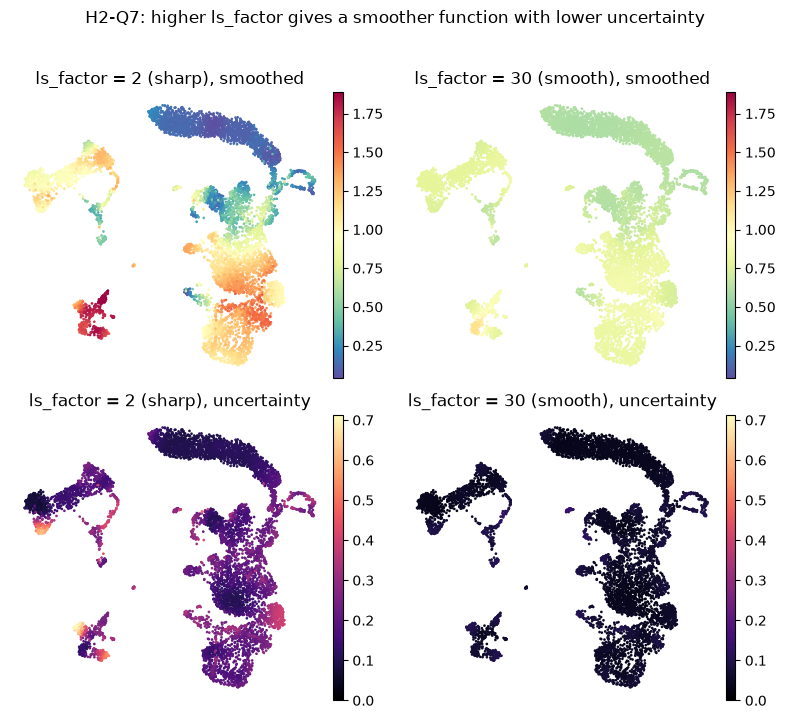

In [13]:
gi = adata.var_names.get_loc(gene)

def _smoothed(key):
    # per-gene smoothed expression is a layer
    v = adata.layers[f"{key}_{c1}_smoothed"][:, gi]
    return np.asarray(v.todense()).ravel() if hasattr(v, "todense") else np.asarray(v).ravel()

def _uncertainty(key):
    # posterior std is a per-cell obs column (shared across genes)
    return np.asarray(adata.obs[f"{key}_{c1}_std"], dtype=float)

cols = {
    "ls_factor = 2 (sharp), smoothed":     _smoothed("kompot_ls_low"),
    "ls_factor = 30 (smooth), smoothed":   _smoothed("kompot_ls_high"),
    "ls_factor = 2 (sharp), uncertainty":  _uncertainty("kompot_ls_low"),
    "ls_factor = 30 (smooth), uncertainty": _uncertainty("kompot_ls_high"),
}
for name, values in cols.items():
    adata.obs[name] = values

names = list(cols)
# Shared color scale within each row so the comparison is honest.
expr = np.concatenate([cols[names[0]], cols[names[1]]])
unc = np.concatenate([cols[names[2]], cols[names[3]]])
row_style = [
    dict(cmap="Spectral_r", vmin=np.nanmin(expr), vmax=np.nanmax(expr)),
    dict(cmap="magma", vmin=0, vmax=np.nanmax(unc)),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for j, name in enumerate(names):
    row = j // 2
    sc.pl.embedding(adata, "umap", color=name, ax=axes[row, j % 2], show=False,
                    frameon=False, title=name, **row_style[row])
fig.suptitle(f"{gene}: higher ls_factor gives a smoother function with lower uncertainty", y=1.02)
plt.tight_layout()

The high-`ls_factor` panels (right) are visibly smoother and, in the bottom row, uniformly
dark (near the bottom of the `magma` scale) — lower posterior uncertainty. The
low-`ls_factor` panels (left) resolve finer spatial structure but light up in the bottom row,
carrying more uncertainty. Default `10` sits between these extremes.

## Resource Planning

Before a long or memory-heavy job, `dry_run=True` estimates memory, disk, and the
fields that would be written — without running anything:

In [14]:
plan = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1="Young",
    condition2="Old",
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    fdr=kompot.FDRSettings(null_genes=2000),
    dry_run=True,
)

RESOURCE USAGE PLAN

System Resources:
  Memory: 530.26 GB available (of 754.57 GB total)
  Disk:   311.62 GB available at /tmp

Total Requirements:
  Memory: 31.76 GB (6% of available)

Memory Allocations:
  • Mellon precision matrix L (condition 1, 2,917/3,116 cells) (np.int64(2917), np.int64(2917)): 64.92 MB
  • Mellon precision matrix L (condition 2, 2,917/3,116 cells) (np.int64(3116), np.int64(3116)): 74.08 MB
  • Smoothed expression (condition 1) (8090, 18285): 1.10 GB → adata.layers['kompot_de_Young_smoothed']
  • Smoothed expression (condition 2) (8090, 18285): 1.10 GB → adata.layers['kompot_de_Old_smoothed']
  • Fold change (8090, 18285): 1.10 GB → adata.layers['kompot_de_Young_to_Old_fold_change']
  • Temporary matrices during predictions (batch_size=100) (100, 5000) + (100, 18285): 17.77 MB
  • Peak intermediate arrays during predictions (~25 arrays) 25×(8090, 18285): 27.55 GB
  • Function predictor covariances (per condition) (5000, 5000): 381.47 MB
  • Combined covariance 

## Cleanup

`cleanup` drops the large smoothed-expression layers but keeps `adata.var` statistics.
Pass `run_ids` to target specific runs:

In [15]:
kompot.cleanup(adata, run_ids=0, analysis_type="de")

[2026-07-28 13:55:33,277] [INFO    ] Cleaned up 3 field(s) from run 0:


[2026-07-28 13:55:33,278] [INFO    ]   layers (3 field(s)):


[2026-07-28 13:55:33,278] [INFO    ]     - kompot_de_Young_smoothed


[2026-07-28 13:55:33,279] [INFO    ]     - kompot_de_Old_smoothed


[2026-07-28 13:55:33,282] [INFO    ]     - kompot_de_Young_to_Old_fold_change


[2026-07-28 13:55:33,282] [INFO    ] Total: Cleaned up 3 field(s) across 1 run(s)


## Where to go deeper

- **[Smoothing expression functions](./05_smooth_expression.ipynb)** — the estimator behind
  DE, covering `ls_factor`, uncertainty, and subset-training for transfer/counterfactuals.
- **[DE with sample variance](./03_sample_variance.ipynb)** — robust significance across replicates.
- **[Differential abundance](./04_differential_abundance.ipynb)** — cell-state frequency changes.
- **[Paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769)** ·
  **[Documentation](https://kompot.readthedocs.io)**